
# Bahrain Tower Recommendation — Validation & Evaluation Notebook

This notebook is designed to run **before** `recommend.py` so you can:
- load and validate the prepared data
- build the tower recommendation scores directly in the notebook
- train a validation AI model for network performance prediction
- test recommendation quality with metrics and visualizations
- review qualitative error analysis, limitations, and ethical considerations

**Expected files**
- `data/processed/features_engineered.csv`
- `data/bahrain_towers.csv` *(optional for some analyses)*

It will try a few common folder layouts automatically.


In [1]:
import warnings, os, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report
)
from sklearn.ensemble import GradientBoostingRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


In [8]:
df = pd.read_csv('../data/processed/features_engineered.csv')
towers = pd.read_csv('../data/bahrain_towers.csv')

print(df.shape)
print(towers.shape)
display(df.head())


(6083, 31)
(2994, 13)


,area,year,quarter,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,nearest_tower_distance_km,tower_count_1km,tower_count_2km,tower_count_5km,visible_tower_count_5km,digital_elevation_model,region_enc,typeOfArea_enc,city_enc,demand_growth_pct,region,typeOfArea,city,block_number,tower_density_ratio,year_trend,area_rolling_d_mbps,area_median_d,area_median_u,area_median_lat,area_test_count,distance_x_density
0,A'ali,2020,1,26.167764,50.516785,34.608000,6.629200,21.200000,52,0.910574,3.200000,10.6,184.000000,126.2,10,2,5,0,0.000000,Northern Governorate,PPLX,A'ali,738,0.017297,0,152.420662,178.857833,23.14375,20.416667,2070,0.004922
1,A'ali,2020,2,26.168586,50.516052,24.785500,8.958833,23.166667,105,0.949577,2.666667,11.5,186.333333,127.0,10,2,5,0,0.000000,Northern Governorate,PPLX,A'ali,714,0.014235,0,34.608000,178.857833,23.14375,20.416667,2070,0.005069
2,A'ali,2020,3,26.168586,50.516052,28.455333,11.872833,25.000000,72,0.949577,2.666667,11.5,186.333333,127.0,10,2,5,0,0.000000,Northern Governorate,PPLX,A'ali,714,0.014235,0,29.696750,178.857833,23.14375,20.416667,2070,0.005069
3,A'ali,2020,4,26.168586,50.516052,51.100167,10.033667,26.833333,137,0.949577,2.666667,11.5,186.333333,127.0,10,2,5,0,0.000000,Northern Governorate,PPLX,A'ali,714,0.014235,0,26.620417,178.857833,23.14375,20.416667,2070,0.005069
4,A'ali,2021,1,26.168586,50.516052,50.347500,9.390667,44.500000,80,0.949577,2.666667,11.5,186.333333,127.0,10,2,5,0,-0.199454,Northern Governorate,PPLX,A'ali,714,0.014235,1,39.777750,178.857833,23.14375,20.416667,2070,0.005069


In [10]:
required_targets = ['avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms']
recommended_id_cols = ['area', 'city', 'region', 'typeOfArea', 'latitude', 'longitude', 'year']

missing_targets = [c for c in required_targets if c not in df.columns]
missing_id = [c for c in recommended_id_cols if c not in df.columns]

print("Missing target columns:", missing_targets if missing_targets else "None")
print("Missing id/context columns:", missing_id if missing_id else "None")

Missing target columns: None
Missing id/context columns: None


In [11]:
df.dtypes

area                          object
year                           int64
quarter                        int64
latitude                     float64
longitude                    float64
avg_d_mbps                   float64
avg_u_mbps                   float64
avg_lat_ms                   float64
tests                          int64
nearest_tower_distance_km    float64
tower_count_1km              float64
tower_count_2km              float64
tower_count_5km              float64
visible_tower_count_5km      float64
digital_elevation_model        int64
region_enc                     int64
typeOfArea_enc                 int64
city_enc                       int64
demand_growth_pct            float64
region                        object
typeOfArea                    object
city                          object
block_number                   int64
tower_density_ratio          float64
year_trend                     int64
area_rolling_d_mbps          float64
area_median_d                float64
a

In [14]:
def minmax(s):
    s = pd.Series(s)
    rng = s.max() - s.min()
    if pd.isna(rng) or rng == 0:
        return pd.Series(np.full(len(s), 0.5), index=s.index)
    return (s - s.min()) / rng

In [18]:
def safe_col(frame, canonical, *alts, default=0.0):
    if canonical in frame.columns:
        return frame[canonical]
    for a in alts:
        if a in frame.columns:
            return frame[a]
    return pd.Series(np.full(len(frame), default), index=frame.index)

In [19]:
def type_label(code):
    mapping = {
        'PPL':  'Populated Place',
        'PPLX': 'Section of Populated Place',
        'HTL':  'Hotel / Tourism',
        'PT':   'Point / landform',
        'ISL':  'Island',
        'ISLX': 'Section of Island',
        'ISLS': 'Islands',
        'PRT':  'Port',
        'TOWR': 'Tower'
    }
    code = str(code).strip()
    return mapping.get(code, code)

In [20]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [21]:
def speed_band(x):
    if x < 100:
        return "Below 100"
    elif x < 300:
        return "100-299"
    elif x < 500:
        return "300-499"
    elif x < 700:
        return "500-699"
    return "700+"

In [24]:
latest_year = df['year'].max()
latest = df[df['year'] == latest_year].copy()

agg = {
    'latitude': 'mean',
    'longitude': 'mean',
    'avg_d_mbps': 'mean',
    'avg_u_mbps': 'mean',
    'avg_lat_ms': 'mean',
    'tests': 'sum' if 'tests' in latest.columns else 'mean',
    'demand_growth_pct': 'mean' if 'demand_growth_pct' in latest.columns else 'mean',
    'typeOfArea': 'first' if 'typeOfArea' in latest.columns else 'count',
    'city': 'first' if 'city' in latest.columns else 'coun',
    'region': 'first' if 'region' in latest.columns else 'count',
}

In [25]:
agg

{'latitude': 'mean',
 'longitude': 'mean',
 'avg_d_mbps': 'mean',
 'avg_u_mbps': 'mean',
 'avg_lat_ms': 'mean',
 'tests': 'sum',
 'demand_growth_pct': 'mean',
 'typeOfArea': 'first',
 'city': 'first',
 'region': 'first'}

In [26]:
optional_aggs = [
    'nearest_tower_distance_km', 'nearest_tower_km',
    'tower_count_1km', 'towers_1km',
    'tower_count_2km',
    'tower_count_5km', 'towers_3km'
]
for c in optional_aggs:
    if c in latest.columns:
        agg[c] = 'mean'

In [27]:
optional_aggs

['nearest_tower_distance_km',
 'nearest_tower_km',
 'tower_count_1km',
 'towers_1km',
 'tower_count_2km',
 'tower_count_5km',
 'towers_3km']

In [31]:
area_df = latest.groupby('area').agg(agg).reset_index()

In [32]:
area_df['nearest_tower_distance_km'] = safe_col(area_df, 'nearest_tower_distance_km', 'nearest_tower_km', default=0.0)
area_df['tower_count_1km'] = safe_col(area_df, 'tower_count_1km', 'towers_1km', default=0.0)
area_df['tower_count_2km'] = safe_col(area_df, 'tower_count_2km', default=0.0)
area_df['tower_count_5km'] = safe_col(area_df, 'tower_count_5km', 'towers_3km', default=0.0)

In [35]:
if 'tests' not in area_df.columns:
    area_df['tests'] = 0
if 'demand_growth_pct' not in area_df.columns:
    area_df['demand_growth_pct'] = 0

W_PERF, W_DEMAND, W_SCARCITY, W_GROWTH = 0.35, 0.30, 0.25, 0.10

area_df['perf_weakness_score'] = 1.0 - minmax(area_df['avg_d_mbps'])
area_df['demand_score'] = minmax(area_df['tests'])
area_df['scarcity_score'] = 1.0 - minmax(area_df['tower_count_5km'])
area_df['growth_score'] = minmax(pd.Series(area_df['demand_growth_pct']).clip(lower=0))

In [37]:
area_df['priority_score'] = (
    W_PERF * area_df['perf_weakness_score'] +
    W_DEMAND * area_df['demand_score'] +
    W_SCARCITY * area_df['scarcity_score'] +
    W_GROWTH * area_df['growth_score']
) * 100

In [39]:
area_df['typeOfArea_label'] = area_df['typeOfArea'].apply(type_label) if 'typeOfArea' in area_df.columns else "Unknown"
top_recommendations = area_df.sort_values('priority_score', ascending=False).reset_index(drop=True)
top_recommendations.insert(0, 'rank', np.arange(1, len(top_recommendations)+1))

In [41]:
display(top_recommendations.head(10))

,rank,area,latitude,longitude,avg_d_mbps,avg_u_mbps,avg_lat_ms,tests,demand_growth_pct,typeOfArea,city,region,nearest_tower_distance_km,tower_count_1km,tower_count_2km,tower_count_5km,perf_weakness_score,demand_score,scarcity_score,growth_score,priority_score,typeOfArea_label
0,1,Ar Rifa` ash Sharqi,26.119838,50.576062,230.802115,28.727322,18.381545,1912,-0.651222,PPLX,Ar Rifa` ash Sharqi,Southern Governorate,1.255329,1.125160,3.185744,21.015126,0.657134,1.000000,0.985517,0.000000,77.637605,Section of Populated Place
1,2,Al Safir Hotel & Tower,26.033984,50.514352,325.989981,43.335612,26.556548,1101,1.228745,HTL,Az Zallaq,Northern Governorate,1.380521,0.233602,1.027282,15.875642,0.509230,0.575615,0.989059,1.000000,69.817968,Hotel / Tourism
2,3,Dumistan,26.131114,50.481690,230.558392,30.529896,20.656556,1086,-0.654360,PPL,Dumistan,Northern Governorate,0.824234,3.893280,23.523591,98.279208,0.657513,0.567766,0.932268,0.000000,63.352605,Populated Place
3,4,Buri,26.147973,50.493317,262.800615,29.906746,21.124875,1164,-0.630711,PPL,Buri,Northern Governorate,0.438412,21.528822,51.080138,115.084273,0.607414,0.608582,0.920686,0.000000,62.534113,Populated Place
4,5,Ar Rifa',26.126345,50.553733,272.417916,33.005887,22.287546,950,-0.690956,PPL,Ar Rifa',Capital Governorate,2.406992,0.000000,0.870879,36.533516,0.592471,0.496599,0.974822,0.000000,60.004984,Populated Place
5,6,Sanad,26.147977,50.578376,289.342218,33.070821,17.316477,1047,-0.666773,PPL,Sanad,Capital Governorate,2.964361,0.000000,0.160819,79.005676,0.566174,0.547357,0.945551,0.000000,59.875573,Populated Place
6,7,Jazirat `Ajirah,25.728158,50.798035,25.450000,10.978000,18.666667,5,-0.772727,ISL,Jazirat `Ajirah,Southern Governorate,23.572317,0.000000,0.000000,0.000000,0.976212,0.002093,1.000000,0.000000,59.230213,Island
7,8,Jusayrah,25.880365,50.568848,127.141333,14.557944,23.666667,22,0.571429,PPL,Jusayrah,Southern Governorate,3.074195,0.805556,0.916667,3.722222,0.818203,0.010989,0.997435,0.465051,58.553149,Populated Place
8,9,Sufalah,26.159496,50.641788,128.159304,16.349128,18.860065,357,-0.670055,PPL,Sufalah,Capital Governorate,1.955216,3.036364,12.362338,54.779870,0.816621,0.186290,0.962247,0.000000,58.226611,Populated Place
9,10,`Ali,26.156106,50.521797,314.274239,38.036561,17.695833,1025,-0.659355,PPL,`Ali,Northern Governorate,1.191379,2.478125,14.169792,114.212500,0.527434,0.535845,0.921287,0.000000,57.567722,Populated Place


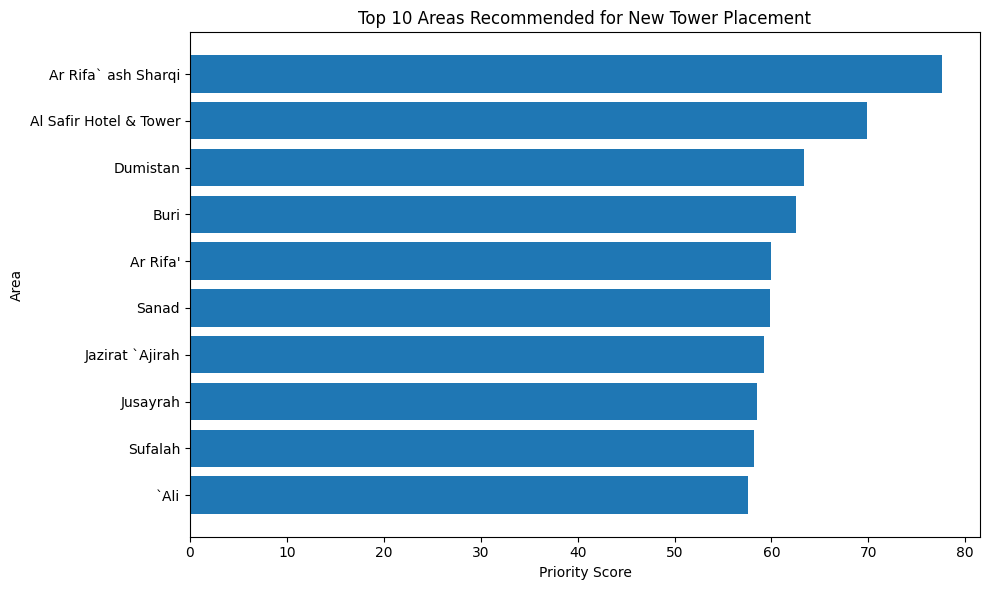

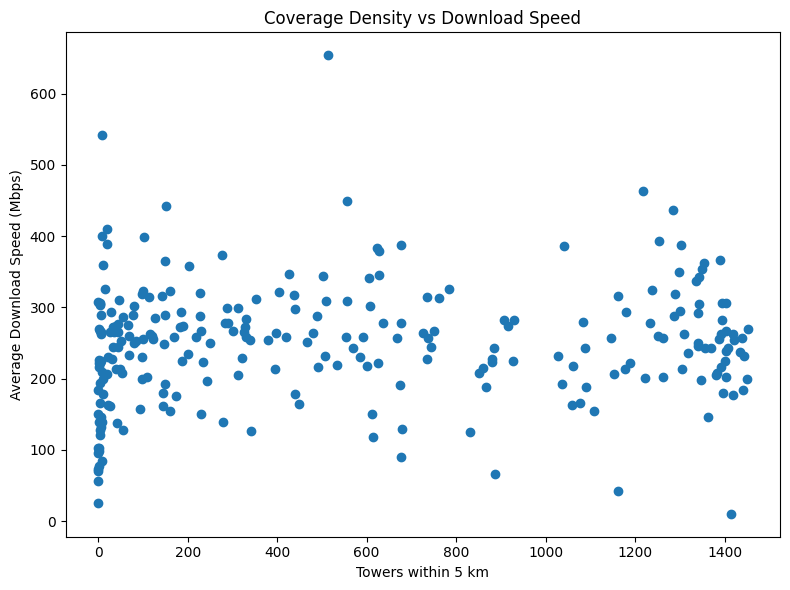

In [42]:
top_n = 10
plot_df = top_recommendations.head(top_n).sort_values('priority_score')

plt.figure(figsize=(10, 6))
plt.barh(plot_df['area'].astype(str), plot_df['priority_score'])
plt.xlabel("Priority Score")
plt.ylabel("Area")
plt.title(f"Top {top_n} Areas Recommended for New Tower Placement")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(area_df['tower_count_5km'], area_df['avg_d_mbps'])
plt.xlabel("Towers within 5 km")
plt.ylabel("Average Download Speed (Mbps)")
plt.title("Coverage Density vs Download Speed")
plt.tight_layout()
plt.show()


In [44]:
candidate_features = [
    'latitude', 'longitude',
    'nearest_tower_distance_km',
    'tower_count_1km', 'tower_count_2km', 'tower_count_5km',
    'tower_density_ratio',
    'digital_elevation_model',
    'region_enc', 'typeOfArea_enc', 'city_enc',
    'demand_growth_pct',
    'year_trend', 'quarter',
    'area_rolling_d_mbps',
    'tests',
    'area_median_d', 'area_median_u', 'area_median_lat',
    'area_test_count',
    'distance_x_density',
]

In [46]:
available_features = [c for c in candidate_features if c in df.columns]

In [47]:
available_features

['latitude',
 'longitude',
 'nearest_tower_distance_km',
 'tower_count_1km',
 'tower_count_2km',
 'tower_count_5km',
 'tower_density_ratio',
 'digital_elevation_model',
 'region_enc',
 'typeOfArea_enc',
 'city_enc',
 'demand_growth_pct',
 'year_trend',
 'quarter',
 'area_rolling_d_mbps',
 'tests',
 'area_median_d',
 'area_median_u',
 'area_median_lat',
 'area_test_count',
 'distance_x_density']

In [49]:
if len(available_features) < 8:
    exclude = {'avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms', 'area', 'city', 'region', 'typeOfArea', 'date', 'last_modified_date'}
    numeric_fallback = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    available_features = sorted(set(available_features).union(numeric_fallback))

In [50]:
print("Using", len(available_features), "features:")
print(available_features)

Using 21 features:
['latitude', 'longitude', 'nearest_tower_distance_km', 'tower_count_1km', 'tower_count_2km', 'tower_count_5km', 'tower_density_ratio', 'digital_elevation_model', 'region_enc', 'typeOfArea_enc', 'city_enc', 'demand_growth_pct', 'year_trend', 'quarter', 'area_rolling_d_mbps', 'tests', 'area_median_d', 'area_median_u', 'area_median_lat', 'area_test_count', 'distance_x_density']


In [51]:
model_df = df[available_features + required_targets + ['year']].copy()
model_df = model_df.dropna(subset=required_targets)
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.fillna(model_df.median(numeric_only=True))
print("Model dataframe shape:", model_df.shape)

Model dataframe shape: (6083, 25)


In [52]:
if 'quarter' in model_df.columns and model_df['year'].nunique() >= 2:
    sort_cols = ['year', 'quarter']
elif model_df['year'].nunique() >= 2:
    sort_cols = ['year']
else:
    sort_cols = None

if sort_cols:
    model_df = model_df.sort_values(sort_cols).reset_index(drop=True)
    split_idx = int(len(model_df) * 0.8)
    train_df = model_df.iloc[:split_idx].copy()
    test_df  = model_df.iloc[split_idx:].copy()
    split_type = "temporal 80/20"
else:
    train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)
    split_type = "random 80/20"

print("Split type:", split_type)
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

X_train = train_df[available_features]
X_test  = test_df[available_features]

targets = ['avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms']
y_train = {t: train_df[t] for t in targets}
y_test  = {t: test_df[t] for t in targets}


Split type: temporal 80/20
Train shape: (4866, 25)
Test shape:  (1217, 25)


In [53]:

# -----------------------------
# Train validation models
# -----------------------------
models = {}
preds = {}
metrics_rows = []

for target in targets:
    model = GradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_depth=5,
        n_estimators=200
    )
    model.fit(X_train, y_train[target])
    y_pred = model.predict(X_test)

    models[target] = model
    preds[target] = y_pred

    metrics_rows.append({
        'target': target,
        'MAE': mean_absolute_error(y_test[target], y_pred),
        'RMSE': rmse(y_test[target], y_pred),
        'R2': r2_score(y_test[target], y_pred),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('target').reset_index(drop=True)
display(metrics_df.round(4))


,target,MAE,RMSE,R2
0,avg_d_mbps,78.1350,112.2602,0.0442
1,avg_lat_ms,14.2166,40.9771,-0.7642
2,avg_u_mbps,9.8082,14.1923,0.0095


In [ ]:

# -----------------------------
# Actual vs predicted plots
# -----------------------------
for target in targets:
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test[target], preds[target], alpha=0.6)
    lims = [
        min(float(np.min(y_test[target])), float(np.min(preds[target]))),
        max(float(np.max(y_test[target])), float(np.max(preds[target])))
    ]
    plt.plot(lims, lims)
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"Actual vs Predicted — {target}")
    plt.tight_layout()
    plt.show()


In [ ]:

# -----------------------------
# Residual analysis
# -----------------------------
for target in targets:
    residuals = y_test[target].values - preds[target]

    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=30)
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Count")
    plt.title(f"Residual Distribution — {target}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.scatter(preds[target], residuals, alpha=0.6)
    plt.axhline(0)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"Residuals vs Predictions — {target}")
    plt.tight_layout()
    plt.show()


In [ ]:

# -----------------------------
# Download speed confusion matrix using bands
# Useful for qualitative telecom interpretation
# -----------------------------
actual_band = pd.Series(y_test['avg_d_mbps']).apply(speed_band)
pred_band = pd.Series(preds['avg_d_mbps']).apply(speed_band)

labels = ["Below 100", "100-299", "300-499", "500-699", "700+"]
cm = confusion_matrix(actual_band, pred_band, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

display(cm_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm_df.values)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted Band")
plt.ylabel("Actual Band")
plt.title("Confusion Matrix — Download Speed Bands")
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, str(cm_df.iloc[i, j]), ha='center', va='center')
plt.tight_layout()
plt.show()

print(classification_report(actual_band, pred_band, labels=labels, zero_division=0))


In [ ]:

# -----------------------------
# Feature importance
# -----------------------------
for target in targets:
    fi = pd.Series(models[target].feature_importances_, index=available_features).sort_values(ascending=False).head(15)
    display(fi.to_frame(f"{target}_importance"))

    plt.figure(figsize=(8, 5))
    plt.barh(fi.index[::-1], fi.values[::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top Feature Importances — {target}")
    plt.tight_layout()
    plt.show()


In [ ]:

# -----------------------------
# Worst prediction examples for error analysis
# -----------------------------
error_df = test_df[['year']].copy()
for target in targets:
    error_df[f'actual_{target}'] = y_test[target].values
    error_df[f'pred_{target}'] = preds[target]
    error_df[f'abs_error_{target}'] = np.abs(y_test[target].values - preds[target])

context_cols = [c for c in ['area', 'city', 'region', 'typeOfArea', 'latitude', 'longitude', 'quarter'] if c in df.columns]
test_context = df.loc[test_df.index, context_cols].reset_index(drop=True) if len(context_cols) else pd.DataFrame()
error_view = pd.concat([test_context, error_df.reset_index(drop=True)], axis=1)

print("Worst 15 download prediction errors:")
display(error_view.sort_values('abs_error_avg_d_mbps', ascending=False).head(15))


In [ ]:

# -----------------------------
# Tower recommendation sanity checks
# -----------------------------
sanity_cols = [
    'rank', 'area', 'city', 'region', 'typeOfArea_label',
    'avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms', 'tests',
    'tower_count_5km', 'demand_growth_pct',
    'perf_weakness_score', 'demand_score', 'scarcity_score', 'growth_score',
    'priority_score'
]
sanity_cols = [c for c in sanity_cols if c in top_recommendations.columns]

print("Top 10 final recommendation candidates:")
display(top_recommendations[sanity_cols].head(10).round(3))



## Qualitative analysis guide

Use the plots and worst-error table above to answer:

**Where the model succeeds**
- Predictions close to the diagonal in the actual-vs-predicted plots
- Residuals centered around zero
- Stronger accuracy in common speed ranges with enough training examples
- Better performance in areas whose features are well represented in historical data

**Where the model struggles**
- Extreme high-speed or low-speed outliers
- Areas with sparse tests or unusual tower distributions
- Locations with changing demand patterns not fully captured by historical features
- Any band confusion visible in the confusion matrix, especially neighboring bands

**Why**
- Limited data coverage in some areas
- Aggregated quarterly statistics may hide local short-term variation
- Recommendation scoring is rule-based and assumes underserved + high demand = best location
- Tower counts alone do not fully capture spectrum, congestion, backhaul quality, or operator-specific behavior



## Limitations and ethical considerations

**Data limitations**
- Historical averages can hide hourly congestion and user-level variability
- Geographic aggregation may blur micro-coverage issues
- Tower data may be incomplete, outdated, or missing operator-specific details

**Model limitations**
- Gradient Boosting can fit nonlinear patterns well, but it is not causal
- Good prediction accuracy does not prove that a new tower alone causes the predicted improvement
- Evaluation depends on the quality of engineered features

**Bias and fairness**
- High-test areas naturally influence the model more than low-test areas
- Rural or low-population areas may be underrepresented
- Recommendations might prioritize dense demand over equitable coverage access

**Leakage risks**
- Be careful that rolling or area-level aggregate features are computed using only past data for real deployment
- Any feature derived using future quarters would overstate performance

**Privacy**
- Speedtest data should remain aggregated and anonymized
- Avoid exposing sensitive user locations or personally identifiable information

**Compute constraints**
- Notebook training is lightweight, but larger models or map-heavy analysis may need more memory


In [ ]:

# -----------------------------
# Optional export
# -----------------------------
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

top_recommendations.to_csv(OUTPUT_DIR / "top_recommendations_from_notebook.csv", index=False)
metrics_df.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
error_view.to_csv(OUTPUT_DIR / "prediction_error_analysis.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())
print("- top_recommendations_from_notebook.csv")
print("- model_metrics.csv")
print("- prediction_error_analysis.csv")



## Final validation checklist

Before you accept the AI solution, check:

1. Do the model metrics look reasonable for download, upload, and latency?
2. Are residuals mostly centered and not wildly skewed?
3. Do top recommended areas make telecom sense:
   - weaker download
   - relatively high demand
   - fewer nearby towers
   - positive demand growth
4. Do the worst-error examples reveal any data-quality issues?
5. Are there any suspicious features that could leak future information?
